# Model annealing
Infer from a cosmological model via Continuous Annealing Langevin Algorithm. 

In [1]:
!python -c "import jax; print(jax.default_backend(), jax.devices())"
import os; os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION']='.15' # NOTE: jax preallocates GPU (default 75%)

import matplotlib.pyplot as plt
import numpy as np
import jax.numpy as jnp
import jax.random as jr
from jax import jit, vmap, grad, debug, lax, flatten_util
from jax.tree_util import tree_map

import numpyro
from numpyro.handlers import seed, condition, trace
from functools import partial
from getdist import plots, MCSamples

%matplotlib inline
%load_ext autoreload 
%autoreload 2

import mlflow
mlflow.set_tracking_uri(uri="http://127.0.0.1:8080")
mlflow.set_experiment("Continuous Tempering Langevin")
from montecosmo.utils import pickle_dump, pickle_load, get_vlim, theme_switch
save_dir = os.path.expanduser("~/scratch/pickles/")

gpu [cuda(id=0)]


2024-02-27 20:14:06.566610: W external/xla/xla/service/gpu/nvptx_compiler.cc:698] The NVIDIA driver's CUDA version is 11.5 which is older than the ptxas CUDA version (11.8.89). Because the driver is older than the ptxas version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


## Import and simulate fiducial

In [21]:
from montecosmo.models import pmrsd_model, prior_model, get_logp_fn, get_score_fn, get_simulator, get_pk_fn, get_param_fn, get_noise_fn
from montecosmo.models import print_config, condition_on_config_mean, default_config as config
# Build and render model
config.update(a_lpt=0.5, mesh_size=32*np.ones(3, dtype=int))
model = partial(pmrsd_model, **config)
print_config(model)

# Get fiducial parameters
fiduc_params = get_simulator(condition_on_config_mean(partial(model, trace_reparam=True)))(rng_seed=0)

# Condition model on observables
# obs_names = ['obs_mesh']
obs_names = ['obs_mesh','Omega_c_','sigma8_','b1_','b2_','bs_','bnl_']
obs_params = {name: fiduc_params[name] for name in obs_names}
observed_model = condition(model, obs_params)

# Get and vectorize relevant functionals
logp_fn = get_logp_fn(observed_model)
score_fn = get_score_fn(observed_model)
pk_fn = get_pk_fn(**config)
param_fn = get_param_fn(**config)
pk_vfn = jit(vmap(vmap(pk_fn)))
param_vfn = jit(vmap(vmap(param_fn)))

# CONFIG
{'mesh_size': array([32, 32, 32]), 'box_size': array([640., 640., 640.]), 'a_lpt': 0.5, 'a_obs': 0.5, 'galaxy_density': 0.001, 'trace_reparam': False, 'trace_deterministic': False, 'prior_config': {'Omega_c': ['{\\Omega}_c', 0.25, 0.1], 'sigma8': ['{\\sigma}_8', 0.831, 0.14], 'b1': ['{b}_1', 1, 0.5], 'b2': ['{b}_2', 0, 0.5], 'bs': ['{b}_s', 0, 0.5], 'bnl': ['{b}_{\\text{nl}}', 0, 0.5]}, 'lik_config': {'obs_std': 1}}

# INFOS
cell_size:        [20.0, 20.0, 20.0] Mpc/h
delta_k:          0.00982 h/Mpc
k_nyquist:        0.15708 h/Mpc
mean_gxy_density: 8.000 gxy/cell



/feynman/work/dphp/hs276503/miniforge3/envs/montecosmoenv/lib/python3.11/site-packages/jax/_src/numpy/array_methods.py:66: UserWarning: Explicitly requested dtype <class 'jax.numpy.int64'> requested in astype is not available, and will be truncated to dtype int32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/google/jax#current-gotchas for more.
  return lax_numpy.astype(arr, dtype)


## Init diffusion

In [81]:
from diffrax import diffeqsolve, ControlTerm, WeaklyDiagonalControlTerm, MultiTerm, ODETerm, VirtualBrownianTree, SaveAt
from diffrax import PIDController, ConstantStepSize, Euler, ReversibleHeun, Heun, EulerHeun
from jax import eval_shape, debug, lax, flatten_util

def get_run_langevin(t0, t1, dt0, ts, score_fn, noise_fn, shape_struct, solver=Euler()):
    drift = lambda t, y, args: score_fn(y, model_kwargs={'noise':noise_fn(t)})
    # diffusion = lambda t, y, args: tree_map(lambda x: 2**.5 * jnp.ones_like(x), y)
    def diffusion(t, y, args):
        n_steps = jnp.floor(t1/dt0)
        lax.cond(jnp.floor(t/dt0)%n_steps, 
                 lambda:None, 
                 lambda:debug.print("t={t}, step={step}/{n_step}, n_nan={n}", 
                                    t=t, step=jnp.floor(t/dt0), n_step=n_steps, n=jnp.isnan(flatten_util.ravel_pytree(y)[0]).sum()))
        return tree_map(lambda x: 2**.5 * jnp.ones_like(x), y)
    saveat = SaveAt(ts=ts, solver_state=True, controller_state=True)
    controller = PIDController(rtol=1e-3, atol=1e-6, pcoeff=0.1, icoeff=0.3, dcoeff=0)
    # controller = ConstantStepSize()

    @jit
    @vmap
    def run_langevin(y, seed):
        brownian_motion = VirtualBrownianTree(t0, t1, tol=jnp.abs(dt0)/10, shape=shape_struct, key=seed)
        terms = MultiTerm(ODETerm(drift), WeaklyDiagonalControlTerm(diffusion, brownian_motion))
        sol = diffeqsolve(terms, solver, t0, t1, dt0=dt0, y0=y, max_steps=int(1e9), saveat=saveat, stepsize_controller=controller)
        return sol
    
    return run_langevin

n_samples = 2
init_simulator = jit(vmap(get_simulator(condition_on_config_mean(partial(prior_model, **config)))))
sample_key, diffeq_key = jr.split(jr.PRNGKey(43), 2)
init_params = init_simulator(jr.split(sample_key, n_samples))
init_params = {name: init_params[name] for name in ['init_mesh_']}
# init_params['init_mesh_'] = (lambda x: jnp.broadcast_to(x, (n_samples,*jnp.shape(x))))(fiduc_params['init_mesh_'])
shape_struct = eval_shape(lambda x: tree_map(lambda y:y[0], x), init_params)
t0, t1, dt0 = 0, 5, 1e-4
ts = jnp.linspace(t0,t1,100)
# noises = jnp.array([2,1.5,1,0.5,0,0])
noises = jnp.array([2])
noise_fn = get_noise_fn(t0, t1, noises, steps=False)

# Const noise
# # t0, t1, dt0 = 0, 10, 4*1e-4
# t0, t1, dt0 = 0, 5, 1e-4
# ts = jnp.linspace(t0,t1,100)
# # noises = jnp.array([3, 1, 0.5, 0])[:,None]
# noises = jnp.array([3,1,0])[:,None]
# solvers = 3*[Heun()]

In [4]:
from jax.flatten_util import ravel_pytree
scores = vmap(score_fn)(init_params, {'noise':jnp.ones(n_samples)})
score_flat = ravel_pytree(scores)[0]
jnp.min(score_flat)*dt0, jnp.max(score_flat)*dt0 # check if steps are not too big

(Array(-0.03297865, dtype=float32), Array(0.01862186, dtype=float32))

In [5]:
mlflow.end_run()
mlflow.start_run(run_name="Pk00 mid noise level")
mlflow.log_params(config)
mlflow.log_params({'n_samples':n_samples,'t0':t0,'t1':t1,'dt0':dt0, 'noises':noises})

pk_init = pk_fn(fiduc_params['init_mesh'])

# Recondition model on new prior
fiduc_params2 = dict(fiduc_params)
# fiduc_params2 = dict(fiduc_params, sigma8_=-2)
fiduc_params2 = fiduc_params2 | param_fn(**fiduc_params2)
pk_init2 = pk_fn(fiduc_params2['init_mesh'])
obs_params2 = {name: fiduc_params2[name] for name in obs_names}
score_fn2 = get_score_fn(condition(model, obs_params2))

params_ = tree_map(lambda x: jnp.broadcast_to(x, (n_samples,len(ts),*jnp.shape(x))), obs_params2)
params_.pop('obs_mesh'); # won't need it 

/feynman/work/dphp/hs276503/miniforge3/envs/montecosmoenv/lib/python3.11/site-packages/jax/_src/numpy/array_methods.py:66: UserWarning: Explicitly requested dtype <class 'jax.numpy.int64'> requested in astype is not available, and will be truncated to dtype int32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/google/jax#current-gotchas for more.
  return lax_numpy.astype(arr, dtype)


## Init field power spectrum convergence

In [95]:
from jax.flatten_util import ravel_pytree

def accept_prob(samples:dict, model, dt=None):
    """
    Return MALA acceptance probability from samples, model, and stepsize.

    If stepsize is None, return Metropolis (symmetric proposal) acceptance probability.
    """
    # Compute the acceptance proba of xk. Positing x-1 = x0, i.e. x0 is accepted almost surely.
    logp_vfn = vmap(get_logp_fn(model))
    samples2 = tree_map(lambda x: jnp.insert(x, 0, x[0], axis=0), samples)
    logp = logp_vfn(samples2)
    logp_diff2 = jnp.diff(logp, axis=0)
    
    logp = logp_vfn(samples)
    # Log probability differences logp(xk) - logp(xk-1)
    logp_diff = jnp.diff(logp, axis=0, prepend=jnp.expand_dims(logp[0],0))

    print("h", logp_diff2, logp_diff)
    if dt is None:
        log_ratio = logp_diff
    else:
        # Sample differences xk - xk-1
        sample_diff = tree_map(lambda x: jnp.diff(x, axis=0, prepend=jnp.expand_dims(x[0],0)), samples)
        sample_diff2 = tree_map(lambda x: jnp.diff(x, axis=0), samples2)
        # Score score(xk)
        score_vfn = vmap(get_score_fn(model))
        score = score_vfn(samples)
        print( ((ravel_pytree(sample_diff)[0] - ravel_pytree(sample_diff2)[0])**2).sum() )
        # Kernel forward log probability logq(xk | xk-1) = -1/(4dt) * ||xk - xk-1 - dt * score(xk-1)||^2
        # If one as access to brownian step, this also equals to -1/2 ||dB||^2
        ker_fwd_logp = tree_map(lambda d,s: d - dt * s, sample_diff, score[:-1])
        ker_fwd_logp = -1/(dt*4) * (ravel_pytree(ker_fwd_logp)[0]**2).sum()
        # Kernel backward log probability logq(xk-1 | xk) = -1/(4dt) * ||xk-1 - xk - dt * score(xk)||^2
        ker_bwd_logp = tree_map(lambda d,s: - d - dt * s, sample_diff, score)
        ker_bwd_logp = -1/(dt*4) * (ravel_pytree(ker_bwd_logp)[0]**2).sum()
        # Log detailed balance ratio logp(xk) - logp(xk-1) + logq(xk-1 | xk) - logq(xk | xk-1)
        log_ratio = logp_diff + ker_bwd_logp - ker_fwd_logp

    return jnp.exp(jnp.minimum(log_ratio, 0))


accept_prob(init_params, observed_model, dt=1e-3)

h [-6.2500000e-02  2.2075312e+04] [    0.    22075.312]
0.0


TypeError: unhashable type: 'slice'

In [66]:
aaa = jnp.ones((10,6))
jnp.insert(aaa, 0, 0.3, axis=0)

Array([[0.3, 0.3, 0.3, 0.3, 0.3, 0.3],
       [1. , 1. , 1. , 1. , 1. , 1. ],
       [1. , 1. , 1. , 1. , 1. , 1. ],
       [1. , 1. , 1. , 1. , 1. , 1. ],
       [1. , 1. , 1. , 1. , 1. , 1. ],
       [1. , 1. , 1. , 1. , 1. , 1. ],
       [1. , 1. , 1. , 1. , 1. , 1. ],
       [1. , 1. , 1. , 1. , 1. , 1. ],
       [1. , 1. , 1. , 1. , 1. , 1. ],
       [1. , 1. , 1. , 1. , 1. , 1. ],
       [1. , 1. , 1. , 1. , 1. , 1. ]], dtype=float32)

In [80]:
aaa = tree_map(lambda x: jnp.insert(x, 0, x[0], axis=0), init_params)['sigma8_']
((aaa[2] - aaa[1])**2).sum(), ((aaa[0] - aaa[2])**2).sum()

(Array(0., dtype=float32), Array(0., dtype=float32))

In [41]:
from jax.tree_util import tree_flatten
from jax.flatten_util import ravel_pytree

tree_flatten(init_params)[0][0].shape, ravel_pytree(init_params)[0].shape

((2, 32, 32, 32), (65536,))

In [22]:
# mlflow.log_metric('halt',0)
# run_langevin = get_run_langevin(t0, t1, dt0, ts, score_fn2, noise_fn, shape_struct, solver=Heun())
# sol = run_langevin(init_params, jr.split(diffeq_key, n_samples))
run = sol.ys
meshes = param_vfn(**dict(params_, init_mesh_=run['init_mesh_']))['init_mesh']
pks = pk_vfn(meshes)
pickle_dump([meshes, pks], save_dir+"meshes_pks_steps.p")
mlflow.log_metric('halt',1);

In [23]:
sol.controller_state, sol.stats

((Array([False, False], dtype=bool),
  Array([False, False], dtype=bool),
  Array([0.00017058, 0.00018274], dtype=float32),
  Array([2.3118281, 1.6229268], dtype=float32),
  Array([1.2635444, 1.1251417], dtype=float32)),
 {'max_steps': Array([1000000000, 1000000000], dtype=int32, weak_type=True),
  'num_accepted_steps': Array([23321, 23241], dtype=int32, weak_type=True),
  'num_rejected_steps': Array([1662, 1638], dtype=int32, weak_type=True),
  'num_steps': Array([24983, 24879], dtype=int32, weak_type=True)})

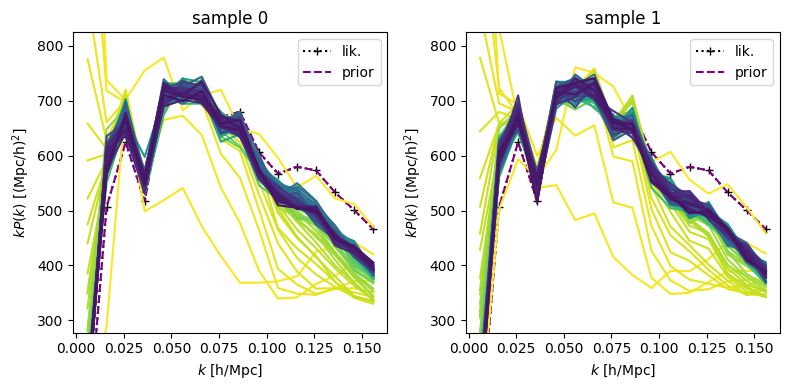

In [44]:
# plot_pk = lambda pk, *args, **kwargs: plt.loglog(pk[0], pk[1], *args, **kwargs)
plot_pk = lambda pk, *args, **kwargs: plt.plot(pk[0], pk[0]*pk[1], *args, **kwargs)
vlim = get_vlim(q=1e-3, scale=1.25)

for dark_theme in [False]:
    theme = theme_switch(dark_theme)
    plt.figure(figsize=(4*n_samples,4))
    for i_sample in range(n_samples):
        plt.subplot(1, n_samples, i_sample+1)
        colors = plt.get_cmap(theme('viridis_r'))(np.linspace(0,.95,len(ts)))
        plt.gca().set_prop_cycle(color=colors)
        plot_pk(pk_init, '+:', color=theme('k'), label="lik.")
        plot_pk(pk_init2, '--', color=theme('purple'), label="prior")
        plt.legend()
        for i_time, time in enumerate(ts):
            plot_pk(pks[i_sample, i_time], label=f"t={time:.1e}")
        plt.title(f"sample {i_sample}")
        plt.ylim(vlim(pks[...,1:].prod(-2)))
        plt.xlabel("$k$ [h/Mpc]"), plt.ylabel(f"$kP(k)$ [(Mpc/h)$^2$]")
    plt.tight_layout()
    mlflow.log_figure(plt.gcf(), f"pk00_midnoise_dth{dark_theme:b}.svg")
    plt.show()

In [45]:
from matplotlib import animation
for dark_theme in [False]:
    theme = theme_switch(dark_theme)
    vlim = get_vlim(q=1e-3, scale=1.25)
    # xx, yy = np.mgrid[[slice(0,box_l,mesh_l*1j) 
    #                 for mesh_l,box_l in zip(config['mesh_size'][:-1],config['box_size'][:-1])]]
    xx, yy = jnp.indices(config['mesh_size'][:-1]) * (config['box_size']/(config['mesh_size']-1))[:-1,None,None]

    i_sample = 0
    toplot_meshes = meshes[i_sample].reshape((-1, *config['mesh_size']))
    diff_meshes = toplot_meshes - fiduc_params['init_mesh']
    n_steps = sol.stats['num_steps'][i_sample]

    proj_meshes = toplot_meshes.mean(axis=-1)
    residual_meshes = diff_meshes.mean(axis=-1)
    # residual_meshes = (diff_meshes**2).mean(axis=(-1))**.5 / fiduc_params['init_mesh'].std()
    rmses = (diff_meshes**2).mean(axis=(-1,-2,-3))**.5 / fiduc_params['init_mesh'].std()

    n_lines = 10
    colors = plt.get_cmap(theme('viridis_r'))(np.linspace(0,1,n_lines))
    pk_traj = pks[i_sample].reshape((-1, *pk_init.shape))
    noise_traj = noise_fn(ts)

    plt.figure(figsize=(lambda h:(2*h*7/6,2*h))(4)) # compensate for colorbars
    plot_mesh = lambda meshes, **kwargs: plt.pcolormesh(xx, yy, meshes[0], 
                                            vmin = np.quantile(meshes, .01), 
                                            vmax = np.quantile(meshes, .99),
                                            **kwargs)
    # plot_pk = lambda pk, *args, **kwargs: plt.loglog(pk[0], pk[1], *args, **kwargs)
    plot_pk = lambda pk, *args, **kwargs: plt.plot(pk[0], pk[0]*pk[1], *args, **kwargs)

    plt.subplot(221)
    quad1 = plot_mesh(proj_meshes, cmap='viridis')
    plt.xlabel("$x$ [Mpc/h]"), plt.ylabel("$y$ [Mpc/h]")
    plt.title("samples")
    plt.colorbar()

    plt.subplot(222)
    quad2 = plot_mesh(residual_meshes, cmap='PRGn')
    plt.xlabel("$x$ [Mpc/h]"), plt.ylabel("$y$ [Mpc/h]")
    plt.title("residuals")
    plt.colorbar()

    ax1 = plt.subplot(223)
    line1, = plt.plot(n_steps*ts/t1, rmses, color=theme('b'))
    ax1.set_zorder(1), ax1.set_frame_on(False)
    plt.xlabel("step"), plt.ylabel("RMSE/$\sigma$", color=theme('b'))
    plt.xlim(0, n_steps), plt.ylim(vlim(rmses))
    plt.twinx()
    plt.ylabel("noise", color=theme("purple"))
    plt.twiny(), plt.xlabel("time")
    line2, = plt.plot(ts, noise_traj, color=theme("purple"))
    plt.xlim(t0, t1), plt.ylim(vlim(noise_traj))
    plt.grid()

    plt.subplot(224)
    plt.gca().set_prop_cycle(color=colors)
    plot_pk(pk_init, '+:', color=theme('k'), label="lik.")
    plot_pk(pk_init2, '--', color=theme('purple'), label="prior")
    plt.legend()
    lines = []
    for i_line in range(n_lines):
        line, = plot_pk(pk_traj[i_line-n_lines])
        lines.append(line)
    title = plt.title(f"noise={noise_fn(0):.2f}")
    plt.ylim(vlim(jnp.concatenate([pk_init[None], pk_init2[None], pk_traj])[...,1:].prod(-2)))
    plt.xlabel("$k$ [h/Mpc]"), plt.ylabel(f"$kP(k)$ [(Mpc/h)$^2$]")
    plt.tight_layout()

    def update(i):
        quad1.set_array(proj_meshes[i])
        quad2.set_array(residual_meshes[i])
        line1.set_data(n_steps*ts[:i]/t1, rmses[:i])
        line2.set_data(ts[:i], noise_traj[:i])

        for i_line, line in enumerate(lines):
            i_traj = i-n_lines+1+i_line
            if i_traj < 0:
                line.set_data([],[])
            else:
                line.set_data(pk_traj[i_traj,0], pk_traj[i_traj,0]*pk_traj[i_traj,1])
            title.set_text(f"noise={noise_fn(i/len(ts)*t1):.2f}")
        return quad1, quad2, line1, line2, *lines, title

    save_name = f"pk00_midnoise_dth{dark_theme:b}"
    mlflow.log_figure(plt.gcf(), save_name+".svg")
    anim = animation.FuncAnimation(plt.gcf(), update, frames=len(ts), interval=100, blit=True)
    plt.close(), anim.save(save_name+".mp4")
    mlflow.log_artifact(save_name+".mp4")
    display(anim)

/tmp/ipykernel_3847393/1144914126.py:53: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  plt.xlim(t0, t1), plt.ylim(vlim(noise_traj))


## Constant noise

In [ ]:
pkss = []
rmsess = []
sol_stats = []

mlflow.log_metric('halt',0)
for i_noise, noise in enumerate(noises):
    print(f"noise {i_noise+1}/{len(noises)}")
    mlflow.log_metric('halt',0)
    noise_fn = get_noise_fn(t0, t1, noise, steps=True)
    run_langevin = get_run_langevin(t0, t1, dt0, ts, score_fn2, noise_fn, shape_struct, solver=solvers[i_noise])
    sol = run_langevin(init_params, jr.split(diffeq_key, n_samples))
    run = sol.ys
    sol_stats.append([sol.stats['num_steps'], sol.controller_state, sol.solver_state])
    _, meshes = cosmo_and_init_vfn(**dict(params_, init_mesh_=run['init_mesh_']))
    pks = pk_vfn(meshes)
    pkss.append(pks)
    diff_meshes = meshes - fiduc_params['init_mesh']
    rmses = (diff_meshes**2).mean(axis=(-1,-2,-3))**.5 / fiduc_params['init_mesh'].std()
    rmsess.append(rmses)
    mlflow.log_metric('halt',1)
pkss = jnp.transpose(jnp.array(pkss), (1,0,2,3,4))
rmsess = jnp.transpose(jnp.array(rmsess), (1,0,2))
save_name = save_dir+f"pkss_rmsess__solvers.p"
pickle_dump([pkss, rmsess], save_name)
mlflow.log_artifact(save_name)
mlflow.log_metric('halt',2);

In [34]:
from matplotlib import animation
from itertools import chain
for dark_theme in [False]:
    theme = theme_switch(dark_theme)
    vlim = get_vlim(q=1e-3, scale=1.25)

    i_sample = 0
    n_lines = 10
    colors = plt.get_cmap(theme('viridis_r'))(np.linspace(0,1,n_lines))
    n_steps = sol.stats['num_steps'][i_sample]

    plt.figure(figsize=(lambda h:(len(noises)*h*7/6,2*h))(4)) # compensate for colorbars
    # plot_pk = lambda pk, *args, **kwargs: plt.loglog(pk[0], pk[1], *args, **kwargs)
    plot_pk = lambda pk, *args, **kwargs: plt.plot(pk[0], pk[0]*pk[1], *args, **kwargs)

    liness = []
    line1s = []
    line2s = []
    for i_noise, noise in enumerate(noises):
        noise_fn = get_noise_fn(t0, t1, noise, steps=True)
        noise_traj = noise_fn(ts)
        pk_traj = pkss[i_sample, i_noise]
        rmses = rmsess[i_sample, i_noise]
        
        ax1 = plt.subplot(2,len(noises),i_noise+1)
        line1, = plt.plot(n_steps*ts/t1, rmses, color=theme('b'))
        line1s.append(line1)
        ax1.set_zorder(1), ax1.set_frame_on(False)
        plt.xlabel("step"), plt.ylabel("RMSE/$\sigma$", color=theme('b'))
        plt.xlim(0, n_steps), plt.ylim(vlim(rmsess))
        plt.twinx()
        plt.ylabel("noise", color=theme("purple"))
        plt.twiny(), plt.xlabel("time")
        line2, = plt.plot(ts, noise_traj, color=theme("purple"))
        line2s.append(line2)
        plt.xlim(t0, t1), plt.ylim(vlim(noises))
        plt.grid()

        plt.subplot(2,len(noises),len(noises)+i_noise+1)
        plt.gca().set_prop_cycle(color=colors)
        plot_pk(pk_init, '+:', color=theme('k'), label="lik.")
        plot_pk(pk_init2, '--', color=theme('purple'), label="prior")
        plt.legend()
        liness.append([])
        for i_line in range(n_lines):
            line, = plot_pk(pk_traj[i_line-n_lines])
            liness[i_noise].append(line)
        title = plt.title(f"noise={noise_fn(t1):.2f}")
        plt.ylim(vlim(jnp.concatenate([pk_init[None], pk_init2[None], pk_traj])[...,1:].prod(-2)))
        plt.xlabel("$k$ [h/Mpc]"), plt.ylabel(f"$kP(k)$ [(Mpc/h)$^2$]")
    plt.tight_layout()

    def update(i):
        for i_noise, noise in enumerate(noises): 
            noise_fn = get_noise_fn(t0, t1, noise, steps=True)
            noise_traj = noise_fn(ts)
            pk_traj = pkss[i_sample, i_noise]
            rmses = rmsess[i_sample, i_noise]
            line1 = line1s[i_noise]
            line2 = line2s[i_noise]
            lines = liness[i_noise]
            line1.set_data(n_steps*ts[:i]/t1, rmses[:i])
            line2.set_data(ts[:i], noise_traj[:i])

            for i_line, line in enumerate(lines):
                i_traj = i-n_lines+1+i_line
                if i_traj < 0:
                    line.set_data([],[])
                else:
                    line.set_data(pk_traj[i_traj,0], pk_traj[i_traj,0]*pk_traj[i_traj,1])
        return *line1s, *line2s, *list(chain(*liness))

    save_name = f"pk00_PID_1em3_dth{dark_theme:b}"
    mlflow.log_figure(plt.gcf(), save_name+".svg")
    anim = animation.FuncAnimation(plt.gcf(), update, frames=len(ts), interval=100, blit=True)
    plt.close()
    anim.save(save_name+".mp4")
    mlflow.log_artifact(save_name+".mp4")
    display(anim)

## Samples analysis

In [ ]:
def plot_cosmo_contours(samples_list, samples_labels, samples_colors, cosmo_names, cosmo_labels, fiduc_cosmo_params):
    if samples_colors is None:
        samples_colors = [{'color':'b', 'alpha':0.3},{'color':'r'}]
    # Triangle plot
    samples_gds = []
    for samples in samples_list:
        samples_arr = np.array(list(samples.values())).T
        samples_gds.append(MCSamples(samples=samples_arr, names=cosmo_names, labels=cosmo_labels))
    gd = plots.get_subplot_plotter(subplot_size=None)
    # gd.settings.solid_colors='tab10_r'
    gd.triangle_plot(roots=samples_gds,
                    markers=fiduc_cosmo_params,
                    filled=True, 
                    legend_labels=samples_labels,
                    line_args=samples_colors,
                    contour_args=samples_colors,)

def plot_summary_table(samples, labels):
    # Plot summary table
    summary_dic = numpyro.diagnostics.summary(samples, group_by_chain=False) # NOTE: group_by_chain if several chains
    summary_arr = [list(list(summary_dic.values())[i].values()) for i in range(len(summary_dic.values()))]

    # Define a custom formatting function to vectorize on summary array
    def format_value(value):
        return f"{value:0.2f}"

    plt.subplot(position=[0,0,1,1]), plt.axis('off')
    # gd.fig.axes[-1]('tight'), plt.axis('tight'), plt.subplots_adjust(top=2), plt.gcf().patch.set_visible(False), 
    plt.table(cellText=np.vectorize(format_value)(summary_arr),
                # rowLabels=list(summary_dic.keys()),
                rowLabels=["$"+label+"$" for label in labels], 
                colLabels=list(list(summary_dic.values())[0].keys()),)